In [2]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;
import gysela_utilities as gysela_utils;
from matplotlib.gridspec import GridSpec

# Styling.
plt.style.use("bmh");

In [3]:
# Test input - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_10/DN_RHTEST_A3_QUIESCENT";
jacobian_dictionary = reader.fetch_jacobian(directory_path);
dt_diag = reader.fetch_dt_diag(directory_path);

/home/thur0011/GYSELA/custom_scripts/GYSELA_utils/post-processing/scripts/phi2D_utilities.py:195: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return np.linspace(0, 2 * np.pi, phi2D_dataset.dims["theta"]);
/home/thur0011/GYSELA/custom_scripts/GYSELA_utils/post-processing/scripts/phi2D_utilities.py:199: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  return np.linspace(0, minor_radius, phi2D_dataset.dims["r"]);
/tmp/ipykernel_1070950/1026318294.py:27: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may

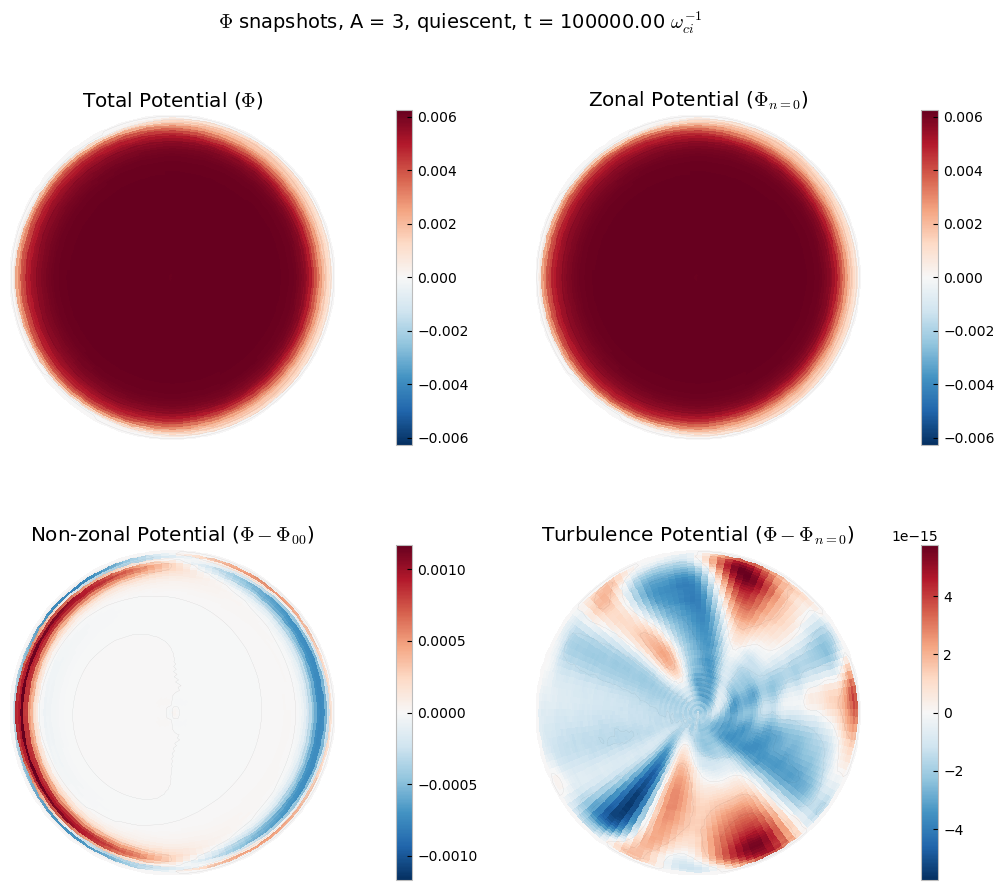

In [5]:
def fetch_dataset_with_time(directory_path, time_step):

	time_in_code_units = time_step * dt_diag;
	dataset = reader.fetch_data_from_h5(f"{directory_path}/sp0/Phi2D/Phi2D_d{time_step:05d}.h5", dimensions = ["zeta", "r", "theta"]);
	return dataset, time_in_code_units;

def plot_phi2D(mesh_grid, phi_dictionary, title_suffix):

	x, y = mesh_grid;
	fig = plt.figure(figsize = (12, 10));
	grid = GridSpec(2, 2, figure = fig, wspace = 0.3, hspace = 0.3);
	fig.suptitle(fr"$\Phi$ snapshots, {title_suffix}", fontsize = 14);
	axes = [
		fig.add_subplot(grid[0, 0]),
		fig.add_subplot(grid[0, 1]),
		fig.add_subplot(grid[1, 0]),
		fig.add_subplot(grid[1, 1])
	];

	for index, dictionary in enumerate(phi_dictionary.values()):
	
		ax = axes[index];
		phi_values = dictionary["data"].values;
		title = dictionary["title"];

		vmax = np.abs(phi_values).max();
		mesh = ax.pcolormesh(x, y, phi_values, vmax = vmax, vmin = -vmax, shading = "auto", cmap = "RdBu_r");
		ax.contour(x, y, phi_values, levels = 8, colors = "k", linewidths = 0.1, alpha = 0.3);
		ax.set_aspect("equal");
		ax.set_title(title);
		ax.axis("off");
		fig.colorbar(mesh, ax = ax, fraction = 0.046, pad = 0.15);

	plt.show();

dataset, time = fetch_dataset_with_time(directory_path, time_step = 2000);
phi_data = utils.generate_phi_dictionary(dataset, jacobian_dictionary);
mesh_grid = utils.generate_xy_grid(dataset);
plot_phi2D(mesh_grid, phi_data, rf"A = 3, quiescent, t = {time:.2f} $\omega_{{ci}}^{{-1}}$");